# Machine Learning Classification Assignment
## M.Tech (AIML/DSE) - Assignment 2

**Author**: Rushikesh Kailash Iname  
**Dataset**: Heart Disease UCI Dataset  
**Models**: 6 Classification Algorithms  
**Metrics**: 6 Evaluation Metrics  

## 1. Import Required Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, 
    roc_auc_score, 
    precision_score, 
    recall_score, 
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load and Explore Dataset

In [2]:
# Load dataset
import pandas as pd
from ucimlrepo import fetch_ucirepo

# Fetch the dataset (Heart Disease dataset, id=45)
heart_disease = fetch_ucirepo(id=45)

# Access the features and target data as pandas DataFrames
X = heart_disease.data.features
y = heart_disease.data.targets

# Combine the features (X) and targets (y) into a single DataFrame (df)
df = pd.concat([X, y], axis=1)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Variable Distribution:")
print(df.iloc[:, -1].value_counts())

Dataset Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



Target Variable Distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 3. Data Preprocessing

In [3]:
# Separate features and target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Create an imputer (example: replace NaN with mean)
imputer = SimpleImputer(strategy='mean')

# 2. Fit and transform your training data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nFeature scaling completed!")

Features shape: (303, 13)
Target shape: (303,)

Training set size: 242
Test set size: 61

Feature scaling completed!


## 4. Model Implementation and Evaluation

In [4]:
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """Calculate all 6 evaluation metrics"""
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred)
    }
    
    # AUC Score
    if y_pred_proba is not None:
        try:
            if len(np.unique(y_true)) == 2:
                metrics['AUC'] = roc_auc_score(y_true, y_pred_proba[:, 1])
            else:
                metrics['AUC'] = roc_auc_score(y_true, y_pred_proba, 
                                               multi_class='ovr', average='weighted')
        except:
            metrics['AUC'] = 0.0
    else:
        metrics['AUC'] = 0.0
    
    return metrics

### 4.1 Logistic Regression

In [5]:
print("="*80)
print("Training: Logistic Regression")
print("="*80)

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)

lr_metrics = calculate_metrics(y_test, lr_pred, lr_proba)

print("\nMetrics:")
for metric, value in lr_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: Logistic Regression

Metrics:
  Accuracy    : 0.6066
  Precision   : 0.5617
  Recall      : 0.6066
  F1          : 0.5821
  MCC         : 0.3637
  AUC         : 0.8287


### 4.2 Decision Tree

In [6]:
print("="*80)
print("Training: Decision Tree")
print("="*80)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_scaled, y_train)

dt_pred = dt_model.predict(X_test_scaled)
dt_proba = dt_model.predict_proba(X_test_scaled)

dt_metrics = calculate_metrics(y_test, dt_pred, dt_proba)

print("\nMetrics:")
for metric, value in dt_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: Decision Tree

Metrics:
  Accuracy    : 0.4426
  Precision   : 0.4474
  Recall      : 0.4426
  F1          : 0.4392
  MCC         : 0.1609
  AUC         : 0.6683


### 4.3 K-Nearest Neighbors

In [7]:
print("="*80)
print("Training: K-Nearest Neighbors")
print("="*80)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_proba = knn_model.predict_proba(X_test_scaled)

knn_metrics = calculate_metrics(y_test, knn_pred, knn_proba)

print("\nMetrics:")
for metric, value in knn_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: K-Nearest Neighbors

Metrics:
  Accuracy    : 0.5246
  Precision   : 0.4419
  Recall      : 0.5246
  F1          : 0.4797
  MCC         : 0.2091
  AUC         : 0.7686


### 4.4 Naive Bayes

In [8]:
print("="*80)
print("Training: Naive Bayes")
print("="*80)

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)
nb_proba = nb_model.predict_proba(X_test_scaled)

nb_metrics = calculate_metrics(y_test, nb_pred, nb_proba)

print("\nMetrics:")
for metric, value in nb_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: Naive Bayes

Metrics:
  Accuracy    : 0.5246
  Precision   : 0.5491
  Recall      : 0.5246
  F1          : 0.5348
  MCC         : 0.2829
  AUC         : 0.8389


### 4.5 Random Forest

In [9]:
print("="*80)
print("Training: Random Forest")
print("="*80)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)

rf_metrics = calculate_metrics(y_test, rf_pred, rf_proba)

print("\nMetrics:")
for metric, value in rf_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: Random Forest

Metrics:
  Accuracy    : 0.5738
  Precision   : 0.4774
  Recall      : 0.5738
  F1          : 0.5199
  MCC         : 0.2826
  AUC         : 0.8256


### 4.6 XGBoost

In [10]:
print("="*80)
print("Training: XGBoost")
print("="*80)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)

xgb_metrics = calculate_metrics(y_test, xgb_pred, xgb_proba)

print("\nMetrics:")
for metric, value in xgb_metrics.items():
    print(f"  {metric:12s}: {value:.4f}")

Training: XGBoost

Metrics:
  Accuracy    : 0.5246
  Precision   : 0.5281
  Recall      : 0.5246
  F1          : 0.5227
  MCC         : 0.2601
  AUC         : 0.7859


## 5. Model Comparison Table

In [11]:
# Create comparison dataframe
results_data = [
    {'ML Model Name': 'Logistic Regression', **lr_metrics},
    {'ML Model Name': 'Decision Tree', **dt_metrics},
    {'ML Model Name': 'KNN', **knn_metrics},
    {'ML Model Name': 'Naive Bayes', **nb_metrics},
    {'ML Model Name': 'Random Forest', **rf_metrics},
    {'ML Model Name': 'XGBoost', **xgb_metrics}
]

df_results = pd.DataFrame(results_data)

# Reorder columns
column_order = ['ML Model Name', 'Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
df_results = df_results[column_order]

print("\n" + "="*100)
print("MODEL COMPARISON TABLE")
print("="*100)
display(df_results.style.format({
    'Accuracy': '{:.4f}',
    'AUC': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1': '{:.4f}',
    'MCC': '{:.4f}'
}).background_gradient(cmap='YlGnBu', subset=['Accuracy', 'AUC', 'F1']))

# Save to CSV
df_results.to_csv('model_comparison_results.csv', index=False)
print("\nResults saved to 'model_comparison_results.csv'")


MODEL COMPARISON TABLE


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.6066,0.8287,0.5617,0.6066,0.5821,0.3637
1,Decision Tree,0.4426,0.6683,0.4474,0.4426,0.4392,0.1609
2,KNN,0.5246,0.7686,0.4419,0.5246,0.4797,0.2091
3,Naive Bayes,0.5246,0.8389,0.5491,0.5246,0.5348,0.2829
4,Random Forest,0.5738,0.8256,0.4774,0.5738,0.5199,0.2826
5,XGBoost,0.5246,0.7859,0.5281,0.5246,0.5227,0.2601



Results saved to 'model_comparison_results.csv'


## 6. Confusion Matrices Visualization

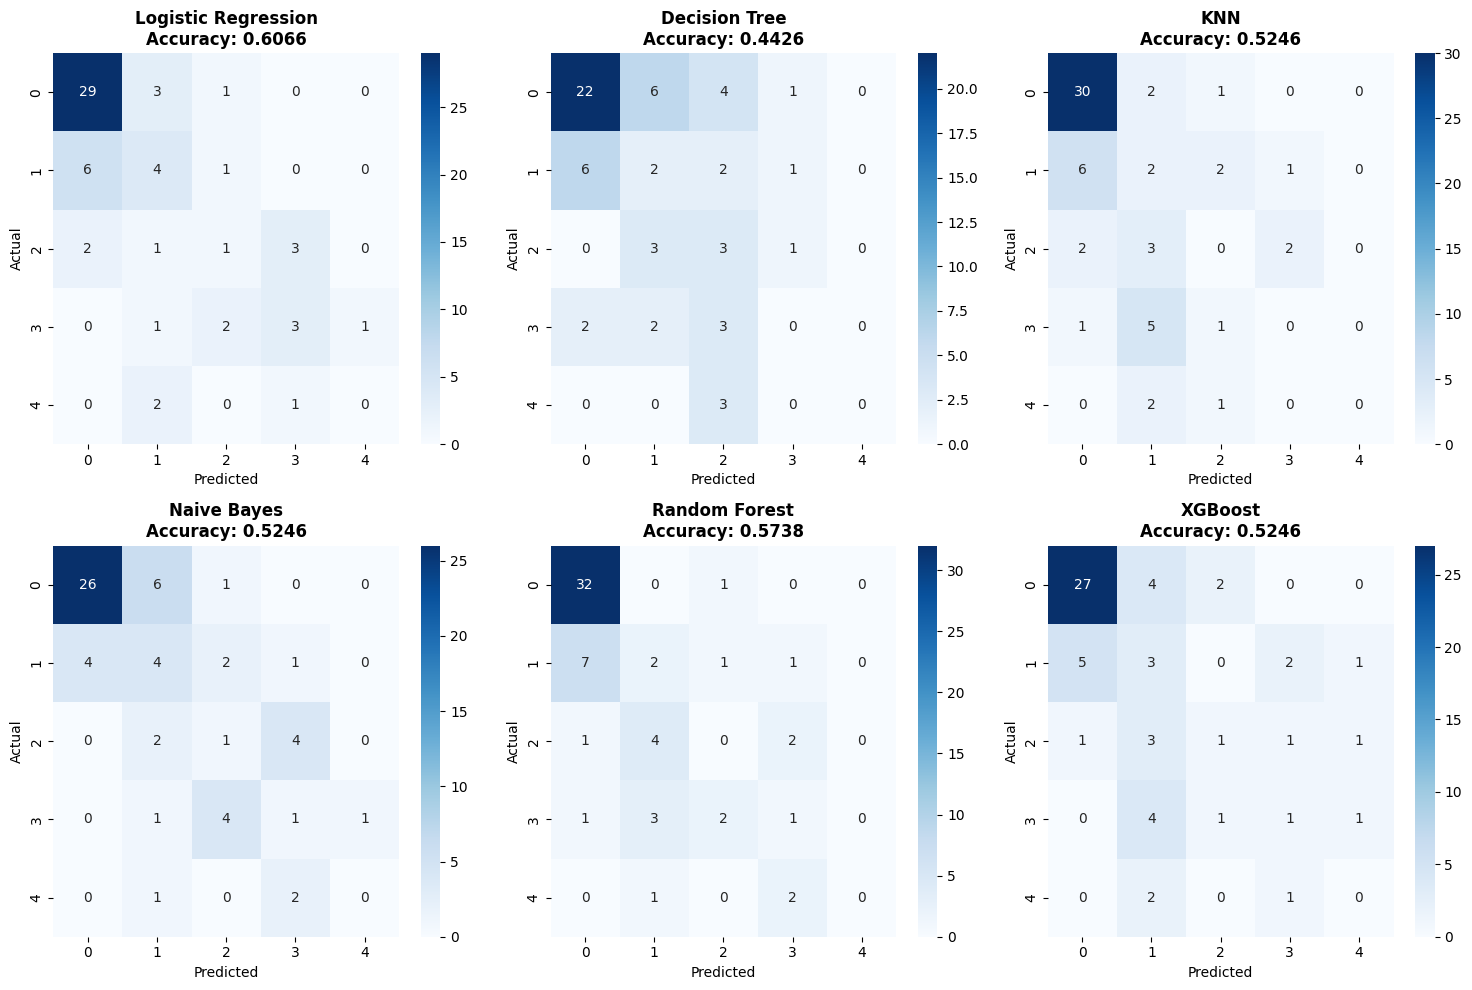

Confusion matrices saved as 'confusion_matrices.png'


In [12]:
# Create confusion matrices
models_pred = [
    ('Logistic Regression', lr_pred, lr_metrics['Accuracy']),
    ('Decision Tree', dt_pred, dt_metrics['Accuracy']),
    ('KNN', knn_pred, knn_metrics['Accuracy']),
    ('Naive Bayes', nb_pred, nb_metrics['Accuracy']),
    ('Random Forest', rf_pred, rf_metrics['Accuracy']),
    ('XGBoost', xgb_pred, xgb_metrics['Accuracy'])
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, pred, acc) in enumerate(models_pred):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{name}\nAccuracy: {acc:.4f}', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved as 'confusion_matrices.png'")

## 7. Model Performance Comparison Chart

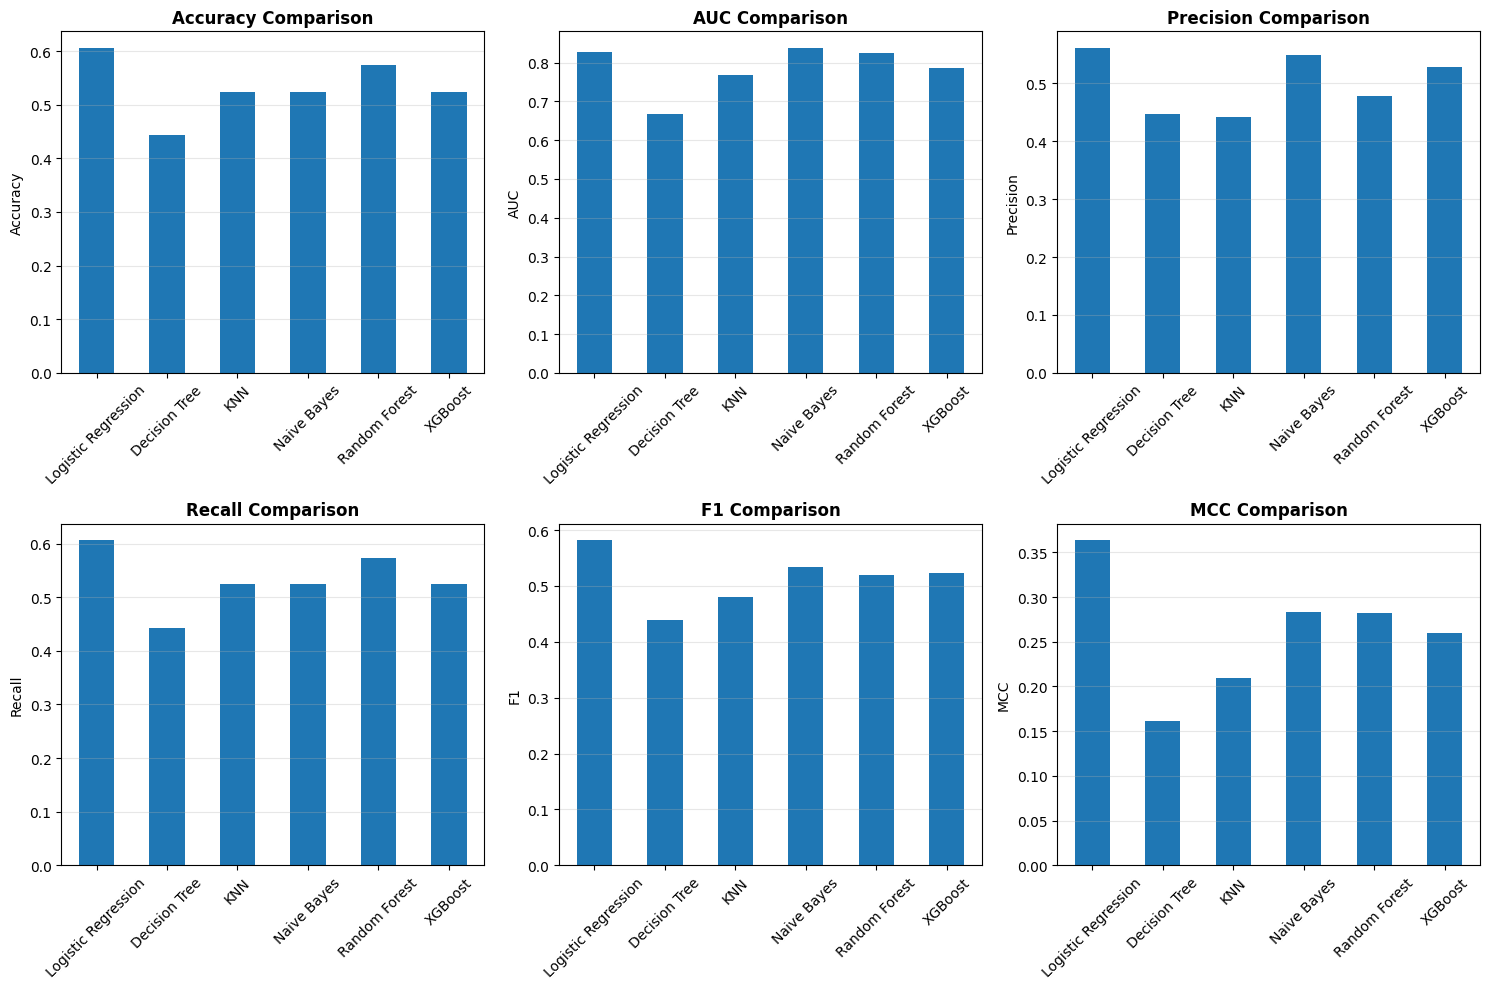

Model comparison charts saved as 'model_comparison_charts.png'


In [13]:
# Create bar plot for model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics_to_plot = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']

for idx, metric in enumerate(metrics_to_plot):
    df_results.plot(x='ML Model Name', y=metric, kind='bar', ax=axes[idx], legend=False)
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("Model comparison charts saved as 'model_comparison_charts.png'")

## 8. Save Trained Models

In [14]:
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("Saved: scaler.pkl")

# Save all models
models = {
    'logistic_regression.pkl': lr_model,
    'decision_tree.pkl': dt_model,
    'knn.pkl': knn_model,
    'naive_bayes.pkl': nb_model,
    'random_forest.pkl': rf_model,
    'xgboost.pkl': xgb_model
}

for filename, model in models.items():
    joblib.dump(model, f'models/{filename}')
    print(f"Saved: {filename}")

print("\nAll models saved successfully to 'models/' directory!")

Saved: scaler.pkl
Saved: logistic_regression.pkl
Saved: decision_tree.pkl
Saved: knn.pkl
Saved: naive_bayes.pkl
Saved: random_forest.pkl
Saved: xgboost.pkl

All models saved successfully to 'models/' directory!


## 9. Summary and Conclusions

In [15]:
print("="*100)
print("SUMMARY")
print("="*100)

best_model_idx = df_results['Accuracy'].idxmax()
best_model = df_results.loc[best_model_idx, 'ML Model Name']
best_accuracy = df_results.loc[best_model_idx, 'Accuracy']

print(f"\nBest Performing Model: {best_model}")
print(f"Accuracy: {best_accuracy:.4f}")

print("\nModel Rankings (by Accuracy):")
ranked = df_results.sort_values('Accuracy', ascending=False)
for idx, row in ranked.iterrows():
    print(f"{idx+1}. {row['ML Model Name']:25s} - {row['Accuracy']:.4f}")

print("\n" + "="*100)
print("ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("="*100)

SUMMARY

Best Performing Model: Logistic Regression
Accuracy: 0.6066

Model Rankings (by Accuracy):
1. Logistic Regression       - 0.6066
5. Random Forest             - 0.5738
3. KNN                       - 0.5246
4. Naive Bayes               - 0.5246
6. XGBoost                   - 0.5246
2. Decision Tree             - 0.4426

ASSIGNMENT COMPLETED SUCCESSFULLY!
